In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import Dense,Flatten,BatchNormalization, Conv2D
import tensorflow_datasets as tfds
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
img_height = 255
img_width = 255
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]','train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)
num_classes=metadata.features['label'].num_classes
label_name = metadata.features['label'].names
print(label_name, ", classnum : ", num_classes)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses'] , classnum :  5


2025-06-24 11:57:16.679167: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
def prepare(ds, shuffle=False, augment=False):
    preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input
    # resize and rescale all datasets
    ds = ds.map(lambda x,y:(tf.image.resize(x,[img_height, img_width]), y), num_parallel_calls=AUTOTUNE)
    
    # 전처리적용
    ds = ds.map(lambda x,y:(preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    
    # batch all datasets
    ds = ds.batch(batch_size)
    
    #use data augmentation only on the training set
    if augment:
        data_augmentation = tf.keras.Sequential([
            layers.RandomFlip("horizontal_and_vertical"),
            layers.RandomRotation(0.2),
        ])
        ds = ds.map(lambda x,y: (data_augmentation(x, training=True), y),num_parallel_calls=AUTOTUNE)
        
    #prefetch()
    return ds.prefetch(buffer_size=AUTOTUNE)

In [4]:
train_ds = prepare(train_ds, shuffle=True, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

In [15]:
#include_top -> ANN부분 직접수정
base_model = tf.keras.applications.MobileNetV3Small(
    weights='imagenet', #load weights pre-trained on ImageNet
    input_shape = (img_height, img_width, 3), include_top = False)

# basemodel 가중치 동결
base_model.trainable=True

inputs = tf.keras.Input(shape=(img_height,img_width,3))
# 추론, 학습에서 다르게 동작하는 layer들은 추론/학습 중 하나로만 동작하게 함.
x=base_model(inputs, training=False)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

/home/hsm/python_ai/intro/.venv/lib/python3.10/site-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [13]:
model.summary()
model.compile(optimizer = 'adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_ds, epochs=15, validation_data=val_ds)
model.save('transfer_learning_flower_2.keras')
with open('history_flower', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 8, 8, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,005 (3.59 MB)

 Trainable params: 2,885 (11.27 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.4907 - loss: 1.2803 - val_accuracy: 0.8038 - val_loss: 0.6139
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.7622 - loss: 0.6566 - val_accuracy: 0.8529 - val_loss: 0.4638
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8146 - loss: 0.5262 - val_accuracy: 0.8692 - val_loss: 0.4001
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8254 - loss: 0.4771 - val_accuracy: 0.8883 - val_loss: 0.3676
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8458 - loss: 0.4425 - val_accuracy: 0.8910 - val_loss: 0.3486
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8588 - loss: 0.4015 - val_accuracy: 0.8937 - val_loss: 0.3382
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8509 - loss: 0.4047 - val_accuracy: 0.8883 - val_loss: 0.3236
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8662 - loss: 0.3781 - val_accuracy: 0.8937 - v

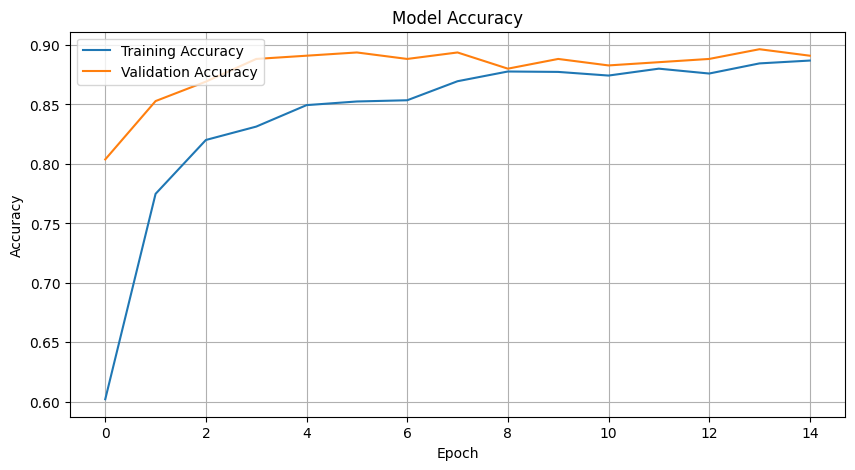

<Figure size 640x480 with 0 Axes>

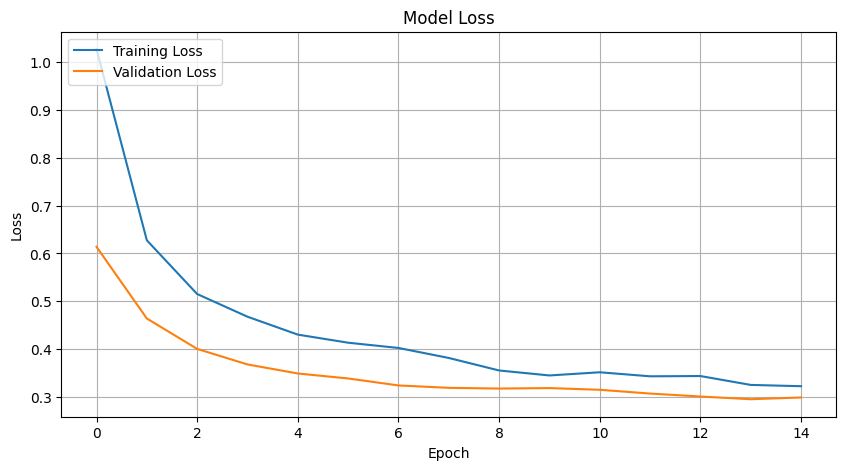

정확도 및 손실 그래프 생성이 완료되었습니다.


<Figure size 640x480 with 0 Axes>

In [14]:

# history 변수는 이미 model.fit()을 통해 채워져 있다고 가정합니다.
# 예를 들어, 실제 코드에서는 다음과 같이 얻어졌을 것입니다:
# history = model.fit(train_ds, epochs=15, validation_data=val_ds)

# --- 1. 정확도 그래프 그리기 ---
plt.figure(figsize=(10, 5)) # 새로운 그림 생성
plt.plot(history.history['accuracy']) # 훈련 정확도
plt.plot(history.history['val_accuracy']) # 검증 정확도
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper left')
plt.grid(True) # 그리드 추가
plt.savefig('model_accuracy_plot.png') # 그래프를 파일로 저장
plt.show(block=False) # 그래프를 표시하고 코드 실행은 계속 (다음 그래프를 위해)
plt.clf() # 현재 그림 초기화

# --- 2. 손실 그래프 그리기 ---
plt.figure(figsize=(10, 5)) # 새로운 그림 생성
plt.plot(history.history['loss']) # 훈련 손실
plt.plot(history.history['val_loss']) # 검증 손실
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper left')
plt.grid(True) # 그리드 추가
plt.savefig('model_loss_plot.png') # 그래프를 파일로 저장
plt.show(block=True) # 그래프를 표시하고 사용자가 창을 닫을 때까지 코드 실행 대기
plt.clf() # 현재 그림 초기화

print("정확도 및 손실 그래프 생성이 완료되었습니다.")